# EJEMPLO Adult Data

https://archive.ics.uci.edu/dataset/2/adult

https://www.kaggle.com/datasets/wenruliu/adult-income-dataset


In [1]:
# Importamos las librerias necesarias
import tensorflow.keras as keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# DATOS

**Radiografía de los Datos (Features)**

El dataset original cuenta con unas 32.561 filas de entrenamiento y 14 variables predictoras, que mezclan datos continuos y categóricos. Estas variables se pueden agrupar en tres grandes dimensiones:

**Variables Demográficas**: Edad (age), sexo (sex), raza (race), estado civil (marital-status), país de origen (native-country) y el rol dentro de la familia (relationship).

**Variables Educativas y Laborales**: Nivel educativo más alto alcanzado (education), los años de estudio cuantificados (education-num), el tipo de empleador (workclass - como sector privado, gobierno o autónomo), el tipo de profesión (occupation) y las horas trabajadas por semana (hours-per-week).

**Variables Financieras y de Muestreo**: Ganancias de capital (capital-gain), pérdidas de capital (capital-loss) y una variable peculiar llamada fnlwgt (final weight), que es un control demográfico que indica a cuántas personas de la población estadounidense representa esa fila específica.

In [2]:
COLUMNS = ["age", "workclass", "fnlwgt", "education", "education_num",
           "marital_status", "occupation", "relationship", "race", "gender",
           "capital_gain", "capital_loss", "hours_per_week", "native_country",
           "income_bracket"]

train_csv = tf.keras.utils.get_file('adult.data',
  'https://download.mlcc.google.com/mledu-datasets/adult_census_train.csv')
test_csv = tf.keras.utils.get_file('adult.data',
  'https://download.mlcc.google.com/mledu-datasets/adult_census_test.csv')

train_df = pd.read_csv(train_csv, names=COLUMNS, sep=r'\s*,\s*',
                       engine='python', na_values="?")
test_df = pd.read_csv(test_csv, names=COLUMNS, sep=r'\s*,\s*', skiprows=[0],
                      engine='python', na_values="?")

3974305/3974305 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# Preprocesamos los datos para simplificar

In [4]:
train_df_num = train_df

In [5]:
# remplazamos categóricas por numéricas
train_df_num['income_bracket'].replace(['<=50K', '>50K'],[0, 1], inplace=True)
train_df_num['race'].replace(["White", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other", "Black"],[0, 1, 2, 3, 4], inplace=True)
train_df_num['gender'].replace(['Male', 'Female'],[0, 1], inplace=True)

/tmp/ipykernel_5125/3163574001.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_num['income_bracket'].replace(['<=50K', '>50K'],[0, 1], inplace=True)
/tmp/ipykernel_5125/3163574001.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df_num['income_bracket'].replace(['<=50K', '>50K'

In [6]:
# Quitamos
train_df_num = train_df_num.drop(['marital_status','occupation','relationship','education','workclass','native_country'], axis='columns')

In [7]:
train_df_num

,age,fnlwgt,education_num,race,gender,capital_gain,capital_loss,hours_per_week,income_bracket
0,39,77516,13,0,0,2174,0,40,0
1,50,83311,13,0,0,0,0,13,0
2,38,215646,9,0,0,0,0,40,0
3,53,234721,7,4,0,0,0,40,0
4,28,338409,13,4,1,0,0,40,0
...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,1,0,0,38,0
32557,40,154374,9,0,0,0,0,40,1
32558,58,151910,9,0,1,0,0,40,0
32559,22,201490,9,0,0,0,0,20,0


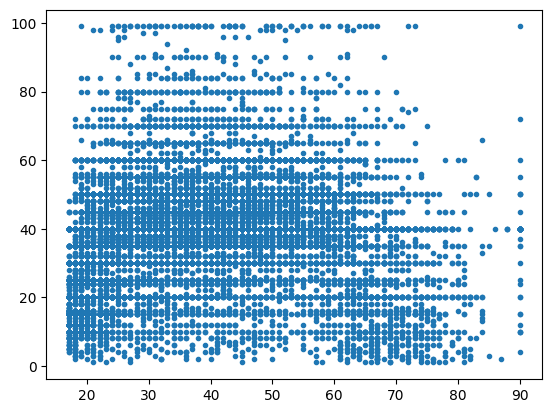

In [8]:
plt.plot(train_df_num['age'],train_df_num['hours_per_week'],'.')

In [9]:
np.corrcoef(train_df_num['gender'],train_df_num['income_bracket'])[0,1]

np.float64(-0.21598015058403627)

In [ ]:
np.corrcoef(train_df_num['race'],train_df_num['income_bracket'])[0,1]

np.float64(-0.09683865434347871)

In [10]:
DATA = train_df_num.values
DATA = DATA.astype('float32')

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Re-establecer X y Y desde train_df_num para asegurar que partimos de datos limpios
# Columnas de train_df_num: age, fnlwgt, education_num, race, gender, capital_gain, capital_loss, hours_per_week, income_bracket
X = train_df_num.drop('income_bracket', axis=1) # Mantener como DataFrame para usar nombres de columna o índices
Y = train_df_num['income_bracket'].values.reshape(-1, 1)

# Identificar índices de columna para X
# X columnas: age(0), fnlwgt(1), education_num(2), race(3), gender(4), capital_gain(5), capital_loss(6), hours_per_week(7)

# Columnas para one-hot encoding (índices 2 y 3 de Python)
categorical_features_indices = [2, 3] # education_num, race

# Columnas para estandarización (características numéricas)
numerical_features_indices = [0, 1, 4, 5, 6, 7] # age, fnlwgt, gender, capital_gain, capital_loss, hours_per_week

# Crear un ColumnTransformer para el preprocesamiento
# Aplicará OneHotEncoder a las columnas categóricas y StandardScaler a las numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_indices),
        ('num', StandardScaler(), numerical_features_indices)
    ],
    remainder='passthrough' # Mantiene otras columnas que no estén especificadas
)

# Aplicar las transformaciones a X
# fit_transform ajusta el preprocesador a los datos y luego los transforma
X_processed = preprocessor.fit_transform(X)

# Ahora, realizar la división de datos (entrenamiento, validación, prueba) en los datos preprocesados
X_train, X_temp, Y_train, Y_temp = train_test_split(X_processed, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print("Datos procesados y divididos correctamente.")
print(f"Nueva forma de X_processed: {X_processed.shape}")
print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de Y_train: {Y_train.shape}")
print(f"Shape de X_val: {X_val.shape}")
print(f"Shape de Y_val: {Y_val.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de Y_test: {Y_test.shape}")

Datos procesados y divididos correctamente.
Nueva forma de X_processed: (32561, 27)
Shape de X_train: (26048, 27)
Shape de Y_train: (26048, 1)
Shape de X_val: (3256, 27)
Shape de Y_val: (3256, 1)
Shape de X_test: (3257, 27)
Shape de Y_test: (3257, 1)


## POR GENERO

In [50]:
N = 10000

x_train = X_train
y_train = Y_train[:,0]

# Variable sensitiva
# 3 race
# 4 gender
s = x_train[:,23]
s = np.asarray(s)

In [51]:
s.shape

()

In [33]:
y_train.shape

(26048,)

In [29]:
A = np.zeros((2,2))
A[0,0] = np.sum(np.argwhere(y_train[np.argwhere(s==0)]==0))
A[0,1] = np.sum(np.argwhere(y_train[np.argwhere(s==0)]==1))
A[1,0] = np.sum(np.argwhere(y_train[np.argwhere(s==1)]==0))
A[1,1] = np.sum(np.argwhere(y_train[np.argwhere(s==1)]==1))
A
A_norm = A
A_norm[0,:] = A[0,:]/sum(A[0,:])
A_norm[1,:] = A[1,:]/sum(A[1,:])

/tmp/ipykernel_5125/1216235546.py:2: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient. Try using != instead.
  A[0,0] = np.sum(np.argwhere(y_train[np.argwhere(s==0)]==0))
/tmp/ipykernel_5125/1216235546.py:3: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient. Try using != instead.
  A[0,1] = np.sum(np.argwhere(y_train[np.argwhere(s==0)]==1))
/tmp/ipykernel_5125/1216235546.py:8: RuntimeWarning: invalid value encountered in divide
  A_norm[0,:] = A[0,:]/sum(A[0,:])
/tmp/ipykernel_5125/1216235546.py:9: RuntimeWarning: invalid value encountered in divide
  A_norm[1,:] = A[1,:]/sum(A[1,:])


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 26048

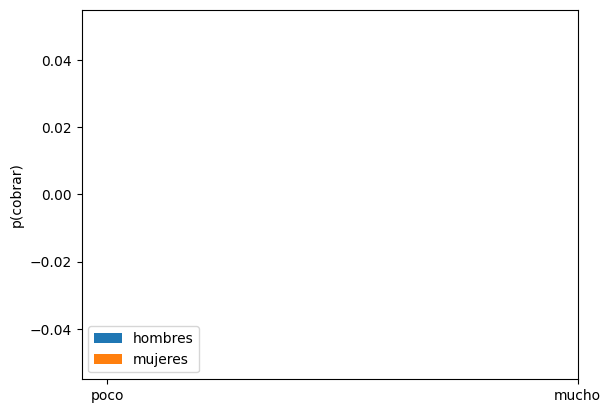

In [30]:
fig, ax = plt.subplots()

width = 0.35
ax.bar([- width/2,1- width/2] ,A_norm[0,:],width,label='hombres')
ax.bar([0+ width/2,1+ width/2] ,A_norm[1,:],width,label='mujeres')
ax.legend()
ax.set_ylabel('p(cobrar)')
#plt.xlabel('cobran')
ax.set_xticks([0,1])
ax.set_xticklabels(['poco','mucho'])
ax.set_title('coor: ' + str(np.corrcoef(s,y_train)[0,1]))

# Modelo simple predictivo

In [66]:
model = keras.Sequential([
    keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],))
])

In [67]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [68]:
Y_val.shape

(3256, 1)

In [69]:
hist = model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_data=(X_val, Y_val))

Epoch 1/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6763 - loss: 0.5916 - val_accuracy: 0.8013 - val_loss: 0.4662
Epoch 2/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8050 - loss: 0.4358 - val_accuracy: 0.8148 - val_loss: 0.4198
Epoch 3/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8112 - loss: 0.4120 - val_accuracy: 0.8185 - val_loss: 0.4063
Epoch 4/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8148 - loss: 0.4035 - val_accuracy: 0.8222 - val_loss: 0.3998
Epoch 5/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8186 - loss: 0.3992 - val_accuracy: 0.8225 - val_loss: 0.3964
Epoch 6/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8196 - loss: 0.3967 - val_accuracy: 0.8237 - val_loss: 0.3936
Epoch 7/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8212 - loss: 0.3951 - val_accuracy: 0.8243 - val_loss: 0.3922
Epoch 8/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8216 - loss: 0.3941 - val_accuracy: 0.

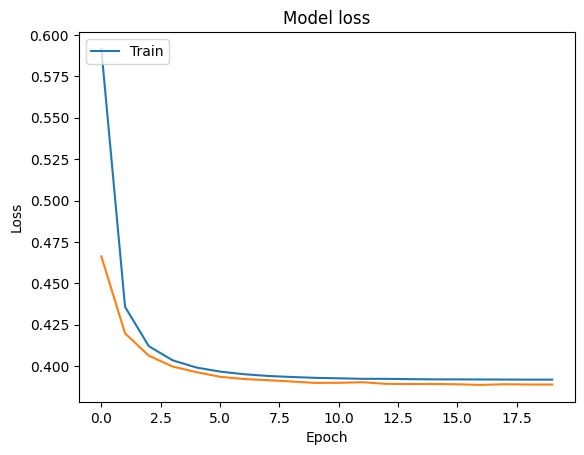

In [70]:
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


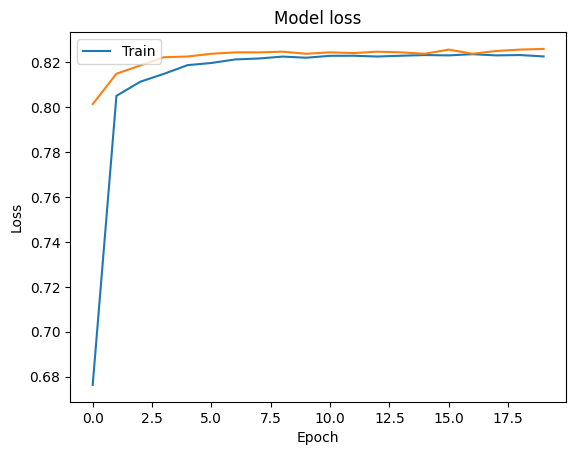

In [71]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


# Crear capa modificada

In [77]:
import keras

class CustomClipValue(keras.constraints.Constraint):
    def __init__(self, min_value, max_value):
        self.min_value = min_value
        self.max_value = max_value

    def __call__(self, w):
        return keras.ops.clip(w, self.min_value, self.max_value)

    def get_config(self):
        return {
            'min_value': self.min_value,
            'max_value': self.max_value,
            'name': self.__class__.__name__
        }

class ExponentLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # Create a trainable weight for each input dimension (feature)
        # Initialize exponents to 1, and apply min/max constraints
        self.exponents = self.add_weight(
            shape=(input_shape[-1],), # Shape matches the number of features
            initializer='ones',      # Initialize all exponents to 1.0
            constraint=CustomClipValue(min_value=0.1, max_value=3.0), # Use the custom ClipValue constraint
            trainable=True,
            name='exponents'
        )
        super().build(input_shape)

    def call(self, inputs):
        # Apply the exponent to each input dimension
        return keras.ops.power(inputs, self.exponents)

    def get_config(self):
        config = super().get_config()
        return config


In [84]:
# SIMPLE
model2 = keras.Sequential([
    ExponentLayer(input_shape=(X_train.shape[1],)),
    keras.layers.Dense(1, activation='sigmoid')
])

# COMPLEJO

model2 = keras.Sequential([
    keras.layers.Dense(10, activation='sigmoid',input_shape=(X_train.shape[1],)),
    ExponentLayer(),
    keras.layers.Dense(1, activation='sigmoid')
])


/tmp/ipykernel_5125/503837151.py:20: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
model2.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ exponent_layer_7                │ (None, 10)             │            10 │
│ (ExponentLayer)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [87]:
hist2 = model2.fit(X_train, Y_train, epochs=20, batch_size=32, validation_data=(X_val, Y_val))

Epoch 1/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.7782 - loss: 0.4758 - val_accuracy: 0.8087 - val_loss: 0.4269
Epoch 2/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8121 - loss: 0.4112 - val_accuracy: 0.8206 - val_loss: 0.4020
Epoch 3/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8204 - loss: 0.3973 - val_accuracy: 0.8283 - val_loss: 0.3914
Epoch 4/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8232 - loss: 0.3910 - val_accuracy: 0.8302 - val_loss: 0.3873
Epoch 5/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8263 - loss: 0.3876 - val_accuracy: 0.8317 - val_loss: 0.3836
Epoch 6/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8258 - loss: 0.3852 - val_accuracy: 0.8308 - val_loss: 0.3823
Epoch 7/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8278 - loss: 0.3828 - val_accuracy: 0.8289 - val_loss: 0.3792
Epoch 8/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8287 - loss: 0.3805 - val_accuracy: 

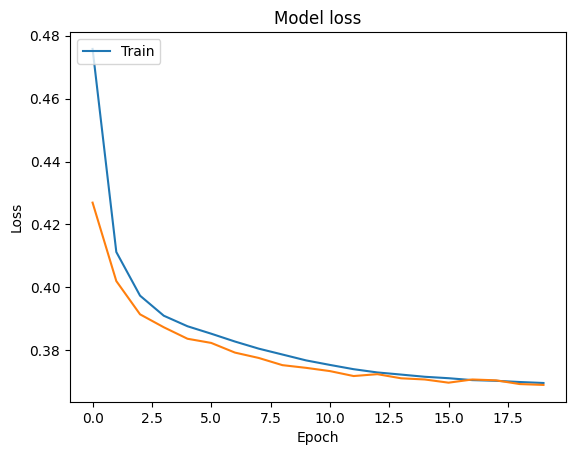

In [88]:
import matplotlib.pyplot as plt

plt.plot(hist2.history['loss'])
plt.plot(hist2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


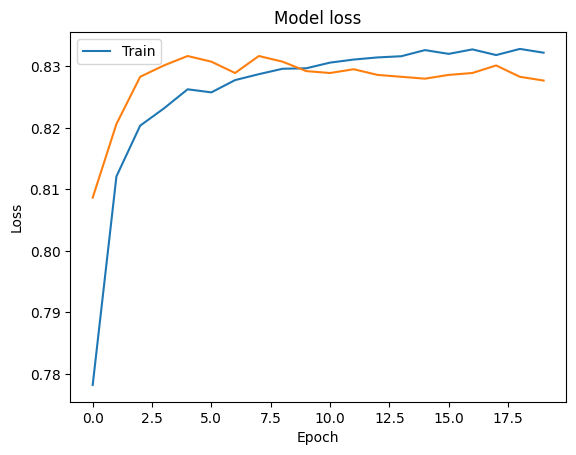

In [89]:
plt.plot(hist2.history['accuracy'])
plt.plot(hist2.history['val_accuracy'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


In [91]:
import scipy.stats
import numpy as np

# Obtener las predicciones del modelo en los datos de entrenamiento
y_pred_proba = model2.predict(X_train)
# Las predicciones son probabilidades, y_pred_proba tiene forma (num_samples, 1)
# Aplanar para obtener un array 1D
y_pred = y_pred_proba.flatten()

# Obtener la variable sensible 's' (género) del conjunto de entrenamiento
# X_train[:, 23] corresponde a la columna de género después del preprocesamiento.
# Puede ser un array 2D (N,1) o una matriz dispersa.
sensitive_variable_gender_raw = X_train[:, 23]

# Convertir a array denso 1D si es un array 2D o una matriz dispersa
if hasattr(sensitive_variable_gender_raw, 'toarray'): # Es una matriz dispersa
    sensitive_variable_gender = sensitive_variable_gender_raw.toarray().flatten()
elif sensitive_variable_gender_raw.ndim > 1: # Es un array denso 2D (N, 1)
    sensitive_variable_gender = sensitive_variable_gender_raw.flatten()
else: # Ya es un array denso 1D
    sensitive_variable_gender = sensitive_variable_gender_raw

# Calcular la correlación de Pearson
pearson_corr, _ = scipy.stats.pearsonr(y_pred, sensitive_variable_gender)
print(f"Correlación de Pearson entre la probabilidad predicha y el género: {pearson_corr:.4f}")

# Calcular la correlación de Spearman
spearman_corr, _ = scipy.stats.spearmanr(y_pred, sensitive_variable_gender)
print(f"Correlación de Spearman entre la probabilidad predicha y el género: {spearman_corr:.4f}")

814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Correlación de Pearson entre la probabilidad predicha y el género: -0.3595
Correlación de Spearman entre la probabilidad predicha y el género: -0.4034


# Vamos a hacer una funcion de coste customizada (FAIR)

In [102]:
import keras
import numpy as np

class CustomFairnessLoss(keras.losses.Loss):
    def __init__(self, lambda_correlation=0.1, name="custom_fairness_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.lambda_correlation = lambda_correlation
        # Usamos BinaryCrossentropy para la parte principal de la pérdida, adecuada para clasificación binaria
        self.bce = keras.losses.BinaryCrossentropy(from_logits=False) # Asumiendo que y_pred_single son probabilidades

    def call(self, y_true_extended, y_pred_single):
        # y_true_extended se espera que sea un tensor con dos columnas: [y_true_real, variable_sensible]
        # y_pred_single es la predicción del modelo (e.g., probabilidad única)

        y_true_actual = y_true_extended[:, 0]
        s_true = y_true_extended[:, 1]

        # Asegurarse de que y_pred_single y s_true sean tensores de una sola columna si vienen con una dimensión extra
        y_pred_single = keras.ops.squeeze(y_pred_single, axis=-1) if y_pred_single.ndim > 1 else y_pred_single
        s_true = keras.ops.squeeze(s_true, axis=-1) if s_true.ndim > 1 else s_true

        # 1. Calcular la pérdida de Entropía Cruzada Binaria (BCE)
        bce_loss = self.bce(y_true_actual, y_pred_single)

        # 2. Calcular la correlación de Pearson (para la penalización)
        # Se añaden epsilons para prevenir divisiones por cero en caso de desviación estándar cero en el lote
        y_pred_mean = keras.ops.mean(y_pred_single)
        s_true_mean = keras.ops.mean(s_true)

        y_pred_centered = y_pred_single - y_pred_mean
        s_true_centered = s_true - s_true_mean

        covariance = keras.ops.mean(y_pred_centered * s_true_centered)

        y_pred_std = keras.ops.std(y_pred_single)
        s_true_std = keras.ops.std(s_true)

        # Corrected: Use keras.backend.epsilon() for numerical stability
        denominator = (y_pred_std * s_true_std) + keras.backend.epsilon() # Epsilon para estabilidad numérica

        correlation = covariance / denominator

        # Penalizar el cuadrado de la correlación para que tienda a cero
        correlation_penalty = keras.ops.square(correlation)

        # Combinar las pérdidas: BCE principal + penalización de correlación
        total_loss = bce_loss + self.lambda_correlation * correlation_penalty
        return total_loss

    def get_config(self):
        config = super().get_config()
        config.update({
            "lambda_correlation": self.lambda_correlation,
        })
        return config

print("Función de coste 'CustomFairnessLoss' creada con éxito usando BinaryCrossentropy y penalización de correlación.")

Función de coste 'CustomFairnessLoss' creada con éxito usando BinaryCrossentropy y penalización de correlación.


In [112]:
loss_custom = CustomFairnessLoss(lambda_correlation=0.9)

In [113]:
# SIMPLE
model3 = keras.Sequential([
    ExponentLayer(input_shape=(X_train.shape[1],)),
    keras.layers.Dense(1, activation='sigmoid')
])

# COMPLEJO

model3 = keras.Sequential([
    keras.layers.Dense(10, activation='sigmoid',input_shape=(X_train.shape[1],)),
    ExponentLayer(),
    keras.layers.Dense(1, activation='sigmoid')
])


/tmp/ipykernel_5125/503837151.py:20: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [114]:
model3.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 10)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ exponent_layer_13               │ (None, 10)             │            10 │
│ (ExponentLayer)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [115]:
model3.compile(optimizer='adam',
              loss=loss_custom,
              metrics=['accuracy'])


In [116]:
Y_train_ext = np.zeros((Y_train.shape[0],2))
Y_train_ext[:,0] = Y_train[:,0]
Y_train_ext[:,1] = X_train[:,23].toarray().flatten()

Y_val_ext = np.zeros((Y_val.shape[0],2))
Y_val_ext[:,0] = Y_val[:,0]
Y_val_ext[:,1] = X_val[:,23].toarray().flatten()

In [117]:
hist3 = model3.fit(X_train, Y_train_ext, epochs=20, batch_size=32, validation_data=(X_val, Y_val_ext))

Epoch 1/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3635 - loss: 0.6005 - val_accuracy: 0.3828 - val_loss: 0.5441
Epoch 2/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3868 - loss: 0.5260 - val_accuracy: 0.3920 - val_loss: 0.4964
Epoch 3/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3982 - loss: 0.4839 - val_accuracy: 0.4010 - val_loss: 0.4632
Epoch 4/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4022 - loss: 0.4622 - val_accuracy: 0.4072 - val_loss: 0.4472
Epoch 5/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4042 - loss: 0.4519 - val_accuracy: 0.4088 - val_loss: 0.4402
Epoch 6/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4055 - loss: 0.4484 - val_accuracy: 0.4099 - val_loss: 0.4358
Epoch 7/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4069 - loss: 0.4421 - val_accuracy: 0.4097 - val_loss: 0.4337
Epoch 8/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4073 - loss: 0.4423 - val_accuracy: 0.

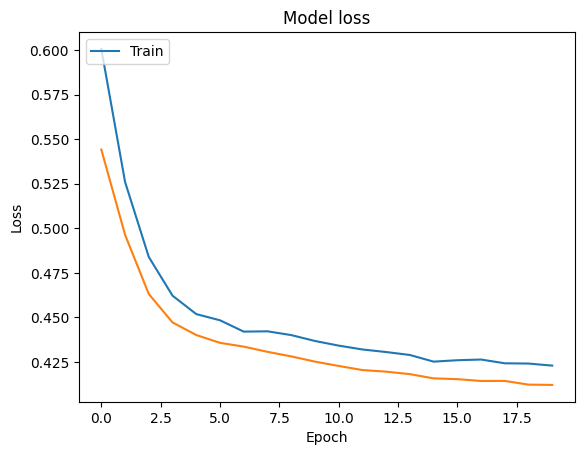

In [118]:
import matplotlib.pyplot as plt

plt.plot(hist3.history['loss'])
plt.plot(hist3.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


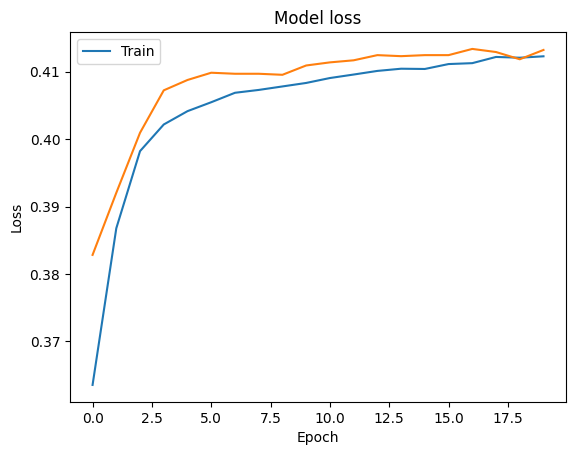

In [119]:
plt.plot(hist3.history['accuracy'])
plt.plot(hist3.history['val_accuracy'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


In [120]:
import scipy.stats
import numpy as np

# Obtener las predicciones del modelo en los datos de entrenamiento
y_pred_proba = model3.predict(X_train)
# Las predicciones son probabilidades, y_pred_proba tiene forma (num_samples, 1)
# Aplanar para obtener un array 1D
y_pred = y_pred_proba.flatten()

# Obtener la variable sensible 's' (género) del conjunto de entrenamiento
# X_train[:, 23] corresponde a la columna de género después del preprocesamiento.
# Puede ser un array 2D (N,1) o una matriz dispersa.
sensitive_variable_gender_raw = X_train[:, 23]

# Convertir a array denso 1D si es un array 2D o una matriz dispersa
if hasattr(sensitive_variable_gender_raw, 'toarray'): # Es una matriz dispersa
    sensitive_variable_gender = sensitive_variable_gender_raw.toarray().flatten()
elif sensitive_variable_gender_raw.ndim > 1: # Es un array denso 2D (N, 1)
    sensitive_variable_gender = sensitive_variable_gender_raw.flatten()
else: # Ya es un array denso 1D
    sensitive_variable_gender = sensitive_variable_gender_raw

# Calcular la correlación de Pearson
pearson_corr, _ = scipy.stats.pearsonr(y_pred, sensitive_variable_gender)
print(f"Correlación de Pearson entre la probabilidad predicha y el género: {pearson_corr:.4f}")

# Calcular la correlación de Spearman
spearman_corr, _ = scipy.stats.spearmanr(y_pred, sensitive_variable_gender)
print(f"Correlación de Spearman entre la probabilidad predicha y el género: {spearman_corr:.4f}")

814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Correlación de Pearson entre la probabilidad predicha y el género: -0.0947
Correlación de Spearman entre la probabilidad predicha y el género: -0.0287


# Prediccion del error (incertidumbre) de prediccion del modelo anterior

In [123]:
y_pred_tr = model3.predict(X_train)
y_pred_val = model3.predict(X_val)



814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [124]:

E_tr = np.abs(y_pred_tr-Y_train)
E_val = np.abs(y_pred_val-Y_val)

In [129]:
# COMPLEJO

model3_S = keras.Sequential([
    keras.layers.Dense(10, activation='sigmoid',input_shape=(X_train.shape[1],)),
    keras.layers.Dense(1, activation='relu')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [130]:
model3_S.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 10)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [131]:
model3_S.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])


In [132]:
hist3_S = model3_S.fit(X_train, E_tr, epochs=20, batch_size=32, validation_data=(X_val, E_val))

Epoch 1/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0467 - mae: 0.1492 - val_loss: 0.0384 - val_mae: 0.1332
Epoch 2/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0398 - mae: 0.1351 - val_loss: 0.0378 - val_mae: 0.1337
Epoch 3/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0393 - mae: 0.1338 - val_loss: 0.0371 - val_mae: 0.1351
Epoch 4/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0385 - mae: 0.1322 - val_loss: 0.0359 - val_mae: 0.1288
Epoch 5/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0375 - mae: 0.1299 - val_loss: 0.0354 - val_mae: 0.1239
Epoch 6/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0368 - mae: 0.1278 - val_loss: 0.0349 - val_mae: 0.1356
Epoch 7/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0361 - mae: 0.1264 - val_loss: 0.0344 - val_mae: 0.1290
Epoch 8/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0357 - mae: 0.1247 - val_loss: 0.0335 - val_mae: 0.1219
Epoch 9/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo

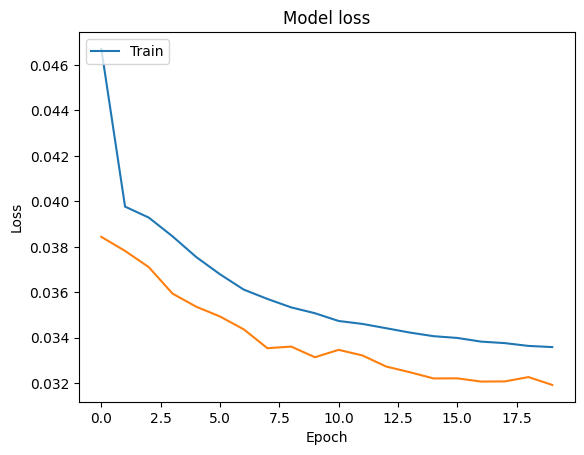

In [133]:
import matplotlib.pyplot as plt

plt.plot(hist3_S.history['loss'])
plt.plot(hist3_S.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


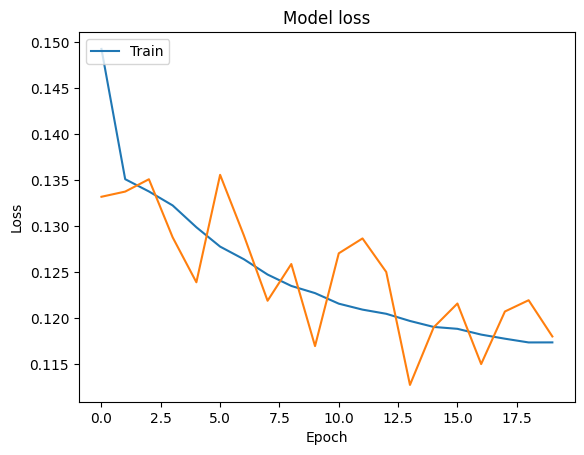

In [134]:
plt.plot(hist3_S.history['mae'])
plt.plot(hist3_S.history['val_mae'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


In [137]:
E_tr_hat = model3_S.predict(X_train)
E_val_hat = model3_S.predict(X_val)

814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


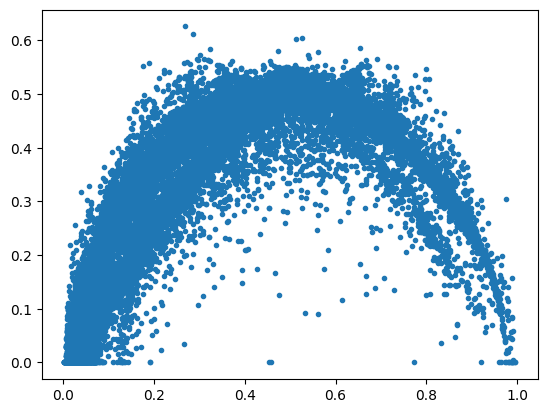

In [139]:
plt.plot(E_tr,E_tr_hat,'.')

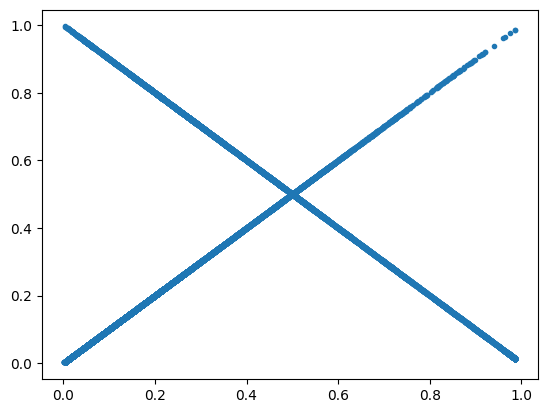

In [141]:
plt.plot(y_pred_tr,E_tr,'.')

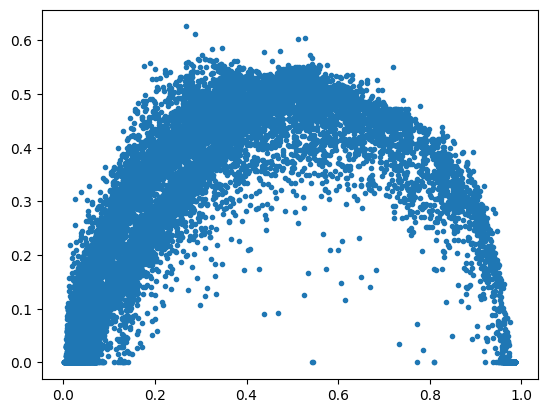

In [142]:
plt.plot(y_pred_tr,E_tr_hat,'.')

### Segunda opcion de incertibdumbre metiendo las y predichas

In [145]:
X_train.shape

(26048, 27)

In [146]:
# Asegurarse de que X_train y X_val sean arrays densos
X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_val_dense = X_val.toarray() if hasattr(X_val, 'toarray') else X_val

# Crear X_train_ext
X_train_ext = np.zeros((X_train_dense.shape[0], X_train_dense.shape[1] + 1))
X_train_ext[:, 0:-1] = X_train_dense
X_train_ext[:, -1] = y_pred_tr.flatten() # Asegurar que y_pred_tr es 1D

# Crear X_val_ext
X_val_ext = np.zeros((X_val_dense.shape[0], X_val_dense.shape[1] + 1))
X_val_ext[:, 0:-1] = X_val_dense
X_val_ext[:, -1] = y_pred_val.flatten() # Asegurar que y_pred_val es 1D

print(f"Shape de X_train_ext: {X_train_ext.shape}")
print(f"Shape de X_val_ext: {X_val_ext.shape}")

Shape de X_train_ext: (26048, 28)
Shape de X_val_ext: (3256, 28)


In [149]:
# COMPLEJO

model3_S = keras.Sequential([
    keras.layers.Dense(10, activation='sigmoid',input_shape=(X_train_ext.shape[1],)),
    keras.layers.Dense(1, activation='relu')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [150]:
model3_S.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 10)             │           290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
model3_S.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])


In [152]:
hist3_S = model3_S.fit(X_train_ext, E_tr, epochs=20, batch_size=32, validation_data=(X_val_ext, E_val))

Epoch 1/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0543 - mae: 0.1657 - val_loss: 0.0379 - val_mae: 0.1321
Epoch 2/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0392 - mae: 0.1325 - val_loss: 0.0368 - val_mae: 0.1313
Epoch 3/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0385 - mae: 0.1306 - val_loss: 0.0363 - val_mae: 0.1280
Epoch 4/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0380 - mae: 0.1293 - val_loss: 0.0357 - val_mae: 0.1217
Epoch 5/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0375 - mae: 0.1284 - val_loss: 0.0351 - val_mae: 0.1247
Epoch 6/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0370 - mae: 0.1269 - val_loss: 0.0350 - val_mae: 0.1325
Epoch 7/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0367 - mae: 0.1264 - val_loss: 0.0344 - val_mae: 0.1246
Epoch 8/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0364 - mae: 0.1255 - val_loss: 0.0343 - val_mae: 0.1277
Epoch 9/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - lo

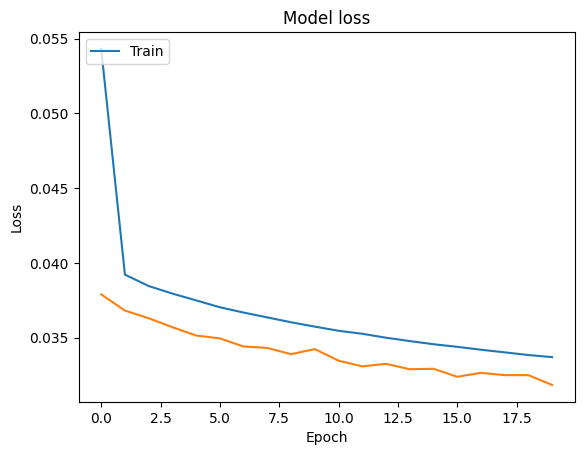

In [155]:
import matplotlib.pyplot as plt

plt.plot(hist3_S.history['loss'])
plt.plot(hist3_S.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


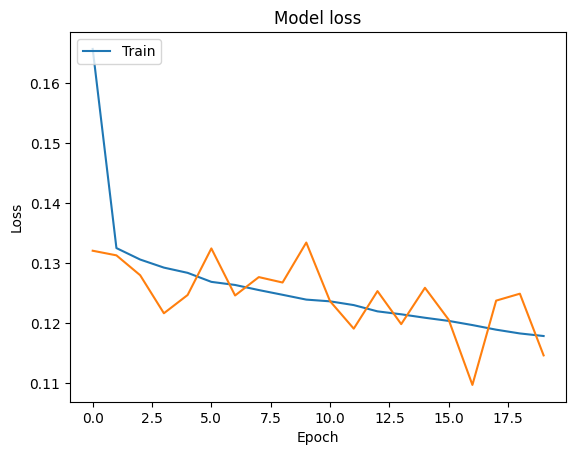

In [156]:
plt.plot(hist3_S.history['mae'])
plt.plot(hist3_S.history['val_mae'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


In [157]:
E_tr_hat = model3_S.predict(X_train_ext)
E_val_hat = model3_S.predict(X_val_ext)

814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


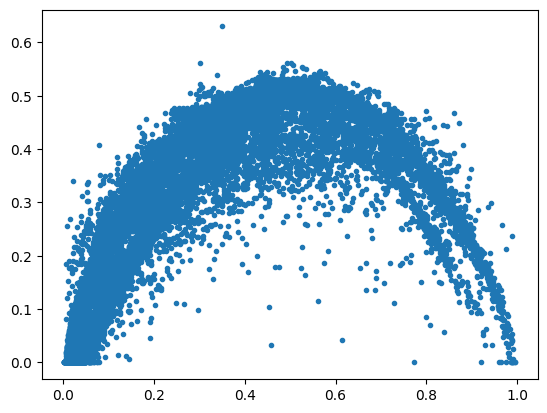

In [158]:
plt.plot(E_tr,E_tr_hat,'.')

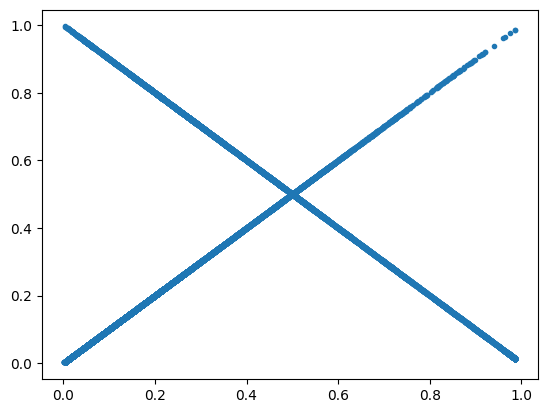

In [159]:
plt.plot(y_pred_tr,E_tr,'.')

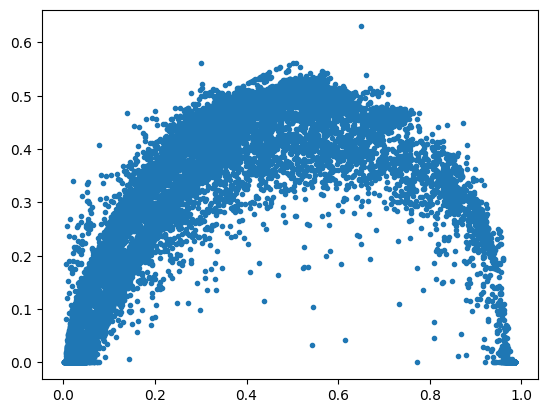

In [160]:
plt.plot(y_pred_tr,E_tr_hat,'.')